In [106]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt

# Projeto 3 - Sinais e Sistemas em Tempo Discreto - 2024/01
# Identificação
## Nome: Leonardo Pereira Côrtes
## Matrícula: 200030582

# Funções utilizadas.

Coloque abaixo as funções desenvolvidas para este projeto.

In [107]:
#Código das funções utilizadas.

# Questão 1

Considere um sinal $x\left(t\right) = 8 \cdot \text{ret}\left(t\right)$, onde:

$$ \begin{align}
	\text{ret}\left(x\right) = \begin{cases}
                               0 & \text{se} ~~ \left|x\right| > \frac{1}{2} \\
															 \frac{1}{2} & \text{se} ~~ \left|x\right| = \frac{1}{2} \\
															 1 & \text{se} ~~ \left|x\right| < \frac{1}{2} \\
                             \end{cases}
\end{align}                             
$$

Considere que o sinal será amostrado a uma taxa $T = \frac{1}{8}$ s, e que queremos uma resolução na frequência de $f_0 = \frac{1}{4}$ Hz. 



## Questão 1a (1.0 ponto)

Obtenha o sinal $x\left[n\right]$, como uma amostragem de $x\left(t\right)$ .

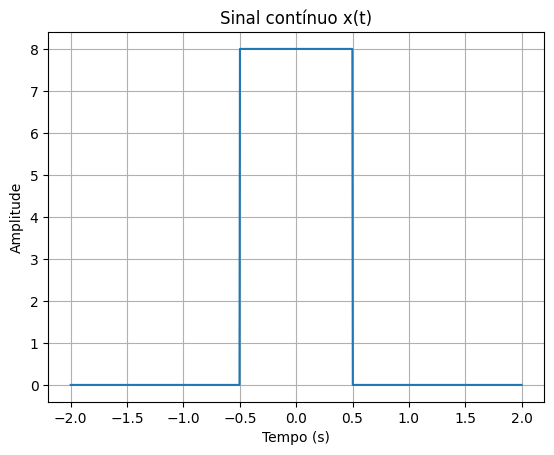

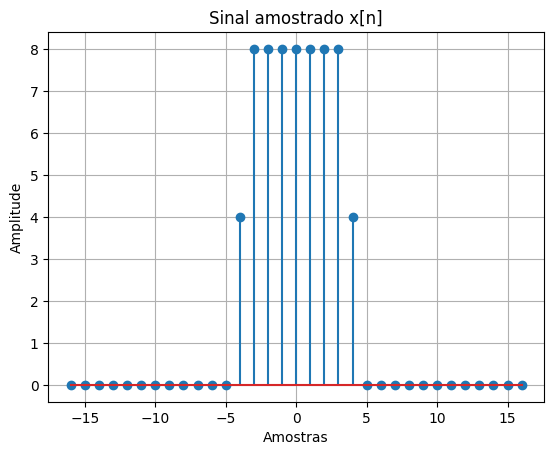

In [108]:
#Resposta da questão 1a
def ret(x):
  if abs(x) > (1/2):
    return 0
  elif abs(x) == (1/2):
    return (1/2)
  elif abs(x) < (1/2):
    return (1)
  
def x(t):
  return 8 * ret(t)

T = (1/8)
f0 = (1/4)

d = (1/f0)
t = np.linspace(-d/2, d/2, 1000)

N = (1/(f0 * T))
n = np.arange(-N//2, N//2 + 1)

x_t = []
for t_i in t:
  x_t.append(x(t_i))

x_n = []
for n_i in n:
  x_n.append(x(n_i * T))

plt.plot(t, x_t)
plt.title('Sinal contínuo x(t)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

plt.stem(n, x_n)
plt.title('Sinal amostrado x[n]')
plt.xlabel('Amostras')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


## Questão 1b (1.0 ponto)

Compare a transformada de Fourier real do sinal $x\left(t\right)$ com a Transformada Discreta de Fourier obtida a partir de $x\left[n\right]$ . 

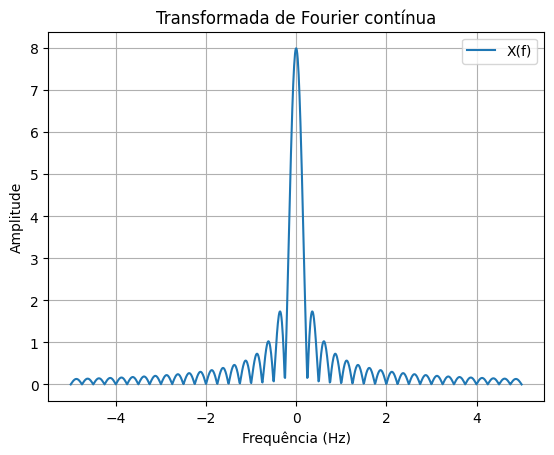

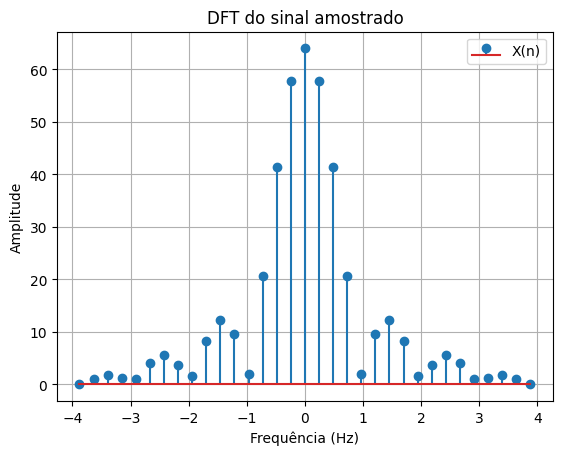

In [109]:
#Resposta da questão 1b
f = np.linspace(-5, 5, 1000)
X_f = 8 * np.sinc(4 * f)

X_n = np.fft.fftshift(np.fft.fft(x_n))
freq = np.fft.fftshift(np.fft.fftfreq(len(x_n), d=T))

plt.plot(f, np.abs(X_f), label="X(f)")
plt.title('Transformada de Fourier contínua')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

plt.stem(freq, np.abs(X_n), label="X(n)")
plt.title('DFT do sinal amostrado')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()


# Questão 2

Considere um sinal $x\left[n\right]$ com $N = 256$ amostras, onde: 
$$
\begin{align}
	x\left[n\right] = \begin{cases}
                               1 & \text{se} ~~ n < 64 \\
															 0 & \text{se} ~~ n \geq 64 \\															 
                             \end{cases}
\end{align}
$$

Considere agora um filtro passa-baixas ideal $H_1$ com frequência de corte normalizada igual a $\frac{1}{16}$.

## Questão 2a (1.0  ponto)

Filtre o sinal $x\left[n\right]$ com o filtro $H_1$, obtendo o sinal $y\left[n\right]$. Compare o sinal original $x\left[n\right]$ com o sinal obtido $y\left[n\right]$. 

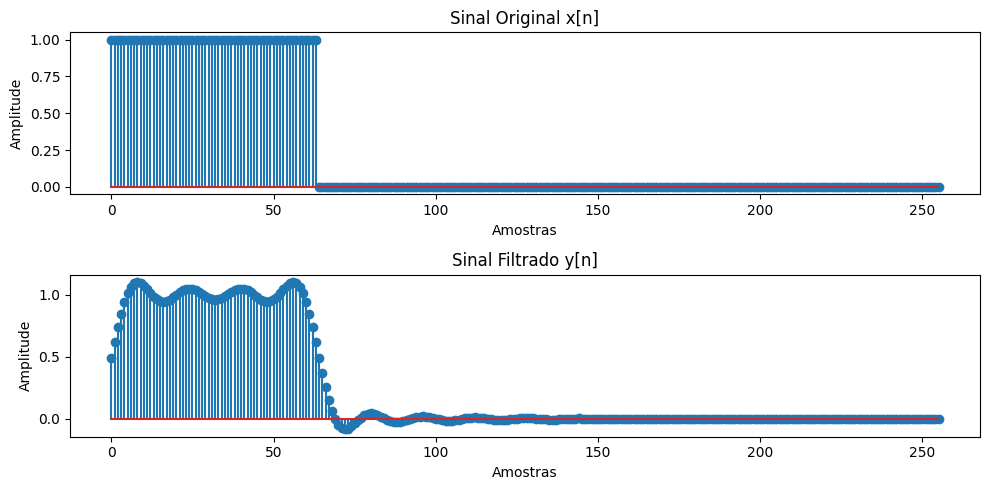

In [110]:
#Resposta da questão 2a
N = 256
x = np.zeros(N)
x[:64] = 1

def passa_baixas(fc, N):
  H = np.zeros(N)
  H = np.sinc(2 * fc * (np.arange(N) - (N-1) / 2))
  H *= np.hamming(N)
  H /= np.sum(H)
  return H

fc = 1/16
H_1 = passa_baixas(fc, N)

y = np.convolve(x, H_1, mode='same')

plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.stem(x)
plt.title('Sinal Original x[n]')
plt.xlabel('Amostras')
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
plt.stem(y)
plt.title('Sinal Filtrado y[n]')
plt.xlabel('Amostras')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

## Questão 2b (1.0 ponto)

Compare o espectro do sinal $x\left[n\right]$ com o espectro do sinal $y\left[n\right]$. 

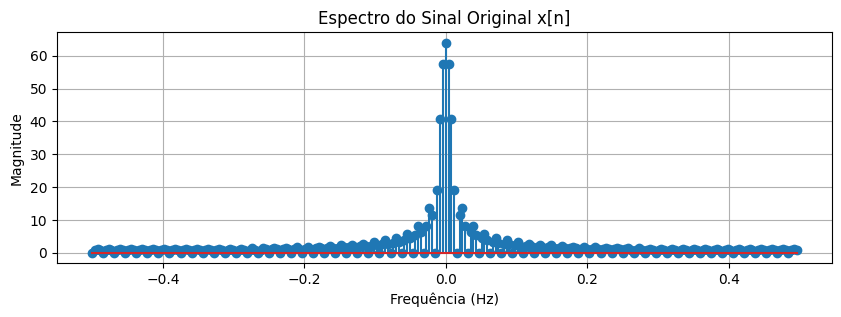

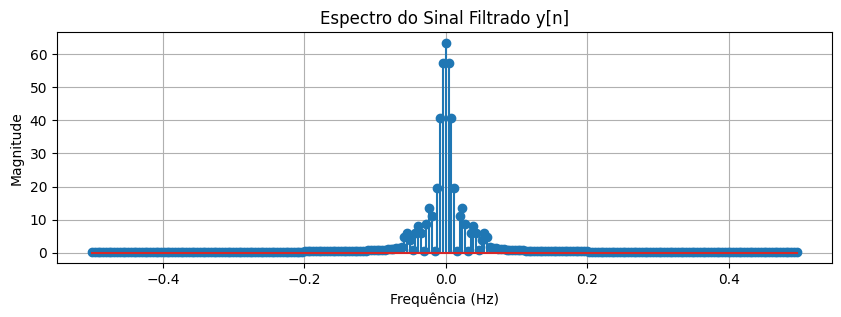

In [111]:
#Resposta da questão 2b
X = np.fft.fft(x)
Y = np.fft.fft(y)

freq = np.fft.fftfreq(N)

plt.figure(figsize=(10, 3))
plt.stem(freq, np.abs(X))
plt.title('Espectro do Sinal Original x[n]')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 3))
plt.stem(freq, np.abs(Y))
plt.title('Espectro do Sinal Filtrado y[n]')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

## Questão 2c (1.0  ponto)

Aplique o filtro $H_1$ no sinal contido no arquivo "noisy_ecg2.mat". Plote o sinal original e o sinal filtrado, bem como seus espectros.


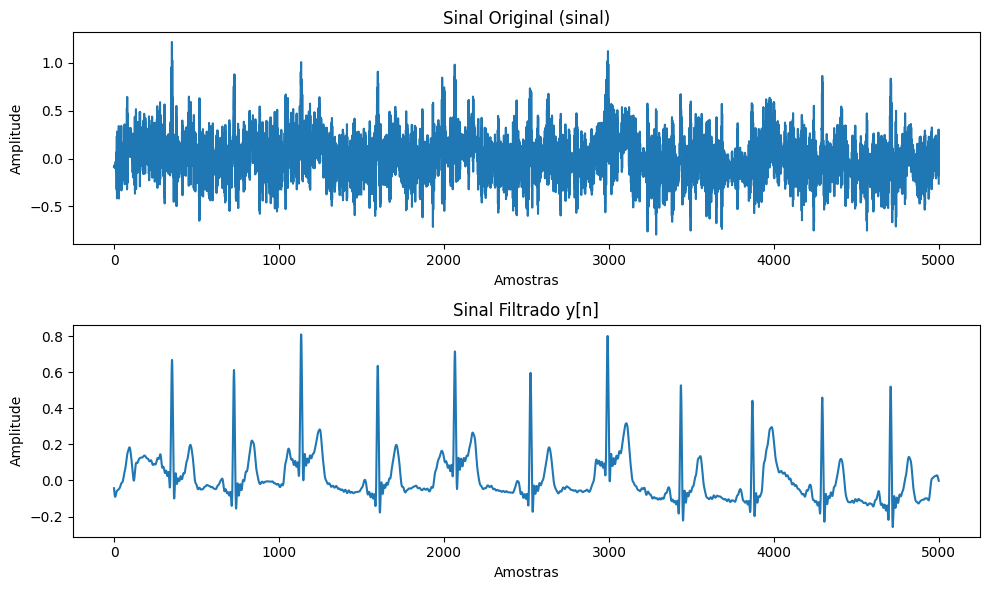

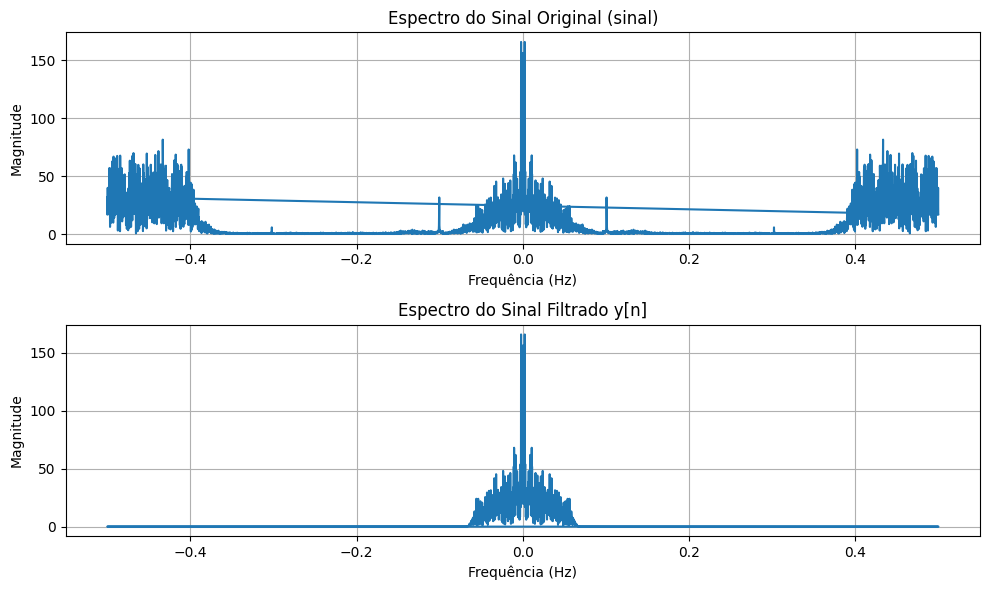

In [112]:
#Resposta da questão 2c

sinal = sp.io.loadmat('noisy_ecg_data_2.mat')['noisy_ecg2'].ravel()

sinal_filtrado = np.convolve(sinal, H_1, mode='same')

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(sinal)
plt.title('Sinal Original (sinal)')
plt.xlabel('Amostras')
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
plt.plot(sinal_filtrado)
plt.title('Sinal Filtrado y[n]')
plt.xlabel('Amostras')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.tight_layout()
plt.show()

sinal_fft = np.fft.fft(sinal)
sinal_filtrado_fft = np.fft.fft(sinal_filtrado)

freq = np.fft.fftfreq(len(sinal))

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(freq, np.abs(sinal_fft))
plt.title('Espectro do Sinal Original (sinal)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(freq, np.abs(sinal_filtrado_fft))
plt.title('Espectro do Sinal Filtrado y[n]')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)

plt.tight_layout()
plt.show()

# Questão 3 (5.0 pontos)

O teclado de um touch-fone usa sinais de diferentes frequências para especificar quais botões foram pressionados. O teclado tem 12 botões, em um arranjo de quatro linhas e três colunas. Quando um botão é pressionado um sinal é gerado pela soma de dois tons senoidais com frequências diferentes. A frequência mais alta indica a coluna da tecla pressionada, enquanto a menor frequência indica a linha da tecla pressionada. As frequências são geradas de acordo com a tabela:

| | | Coluna | |
| :-: | :-: | :-: | :-: |
| Linha | 1209 Hz | 1336 Hz | 1477 Hz |
| 697 Hz | 1 | 2 | 3 |
| 770 Hz | 4 | 5 | 6 |
| 852 Hz | 7 | 8 | 9 |
| 940 Hz | | 0 | |

A frequência de amostragem é de 8192 Hz, e o som de cada tecla dura um segundo. Escreva um programa que decodifique, de forma automática, um sinal composto por um número de telefone gerado com essas características. Teste o seu programa com os sinais encontrados no arquivo "touch_fone.mat".


In [113]:
#Resposta da questão 3
sinal1 = sp.io.loadmat('touch_fone.mat')['x'].ravel()
sinal2 = sp.io.loadmat('touch_fone.mat')['y'].ravel()
sinal3 = sp.io.loadmat('touch_fone.mat')['z'].ravel()

fs = 8192 
freq_linhas = [697, 770, 852, 940]
freq_colunas = [1209, 1336, 1477]

teclas = [['1', '2', '3'],
          ['4', '5', '6'],
          ['7', '8', '9'],
          ['', '0', '']]

def decode(sinal):
	dft = np.fft.fft(sinal)

	freq = np.fft.fftfreq(fs, d=1/fs)
	picos, _ = sp.signal.find_peaks(np.abs(dft), height=200)
 
	freq_picos = np.abs(freq[picos])

	linha = np.argmin(np.abs(freq_linhas - min(freq_picos)))
	coluna = np.argmin(np.abs(freq_colunas - max(freq_picos)))

	return teclas[linha][coluna]

tel1 = ''
for i in range(0, len(sinal1), fs):
	tel1 += decode(sinal1[i:i+fs])

tel2 = ''
for i in range(0, len(sinal2), fs):
	tel2 += decode(sinal2[i:i+fs])

tel3 = ''
for i in range(0, len(sinal3), fs):
	tel3 += decode(sinal3[i:i+fs])

print('Telefone 1:', tel1)
print('Telefone 2:', tel2)
print('Telefone 3:', tel3)

Telefone 1: 31075580
Telefone 2: 911
Telefone 3: 2446712
